## Deep Learning Forecasting dengan Cyclical Temporal Features

 Deep Learning tanpa decomposition:
- Uni-LSTM CI
- Uni-LSTM RE
- Multi-LSTM
- BiLSTM CI
- BiLSTM RE
- BiLSTM Multi

Input menggunakan PACF-based lag features + cyclical time features:
`hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`, `month_sin`, `month_cos`.

Konfigurasi dibuat konsisten dengan baseline dummy:
- temporal split 80:20
- MinMaxScaler fit pada training data saja
- look-back = 24
- one-step ahead
- seed = 42
- epochs = 50
- batch size = 32
- validation split = 0.1
- early stopping patience = 10
- shuffle = False


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Project root
project_root = next(
    (
        parent
        for parent in [Path.cwd(), *Path.cwd().parents]
        if (parent / "src").exists()
    ),
    Path.cwd()
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import TimeSeriesDataLoader
from src.models.deep_learning import LSTMForecaster
from src.evaluation.metrics import ModelEvaluator

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

loader = TimeSeriesDataLoader()

print("Project root:", project_root)
print("TensorFlow:", tf.__version__)


Project root: /Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app
TensorFlow: 2.21.0


In [2]:
feature_path = (
    project_root
    / "data"
    / "processed"
    / "normalized"
    / "dataset_feature_engineered.csv"
)

df = pd.read_csv(feature_path)

df["datetime"] = pd.to_datetime(
    df["datetime"],
    utc=True
)

df = (
    df
    .set_index("datetime")
    .sort_index()
)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (17496, 84)

Columns:
['carbon_intensity', 'renewable_percentage', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'CI_lag_1', 'CI_lag_3', 'CI_lag_4', 'CI_lag_5', 'CI_lag_6', 'CI_lag_7', 'CI_lag_8', 'CI_lag_9', 'CI_lag_10', 'CI_lag_11', 'CI_lag_12', 'CI_lag_13', 'CI_lag_14', 'CI_lag_15', 'CI_lag_16', 'CI_lag_17', 'CI_lag_18', 'CI_lag_19', 'CI_lag_20', 'CI_lag_21', 'CI_lag_22', 'CI_lag_23', 'CI_lag_24', 'CI_lag_25', 'CI_lag_26', 'CI_lag_27', 'CI_lag_29', 'CI_lag_30', 'CI_lag_31', 'CI_lag_32', 'CI_lag_35', 'CI_lag_36', 'CI_lag_40', 'CI_lag_41', 'CI_lag_44', 'CI_lag_45', 'CI_lag_46', 'CI_lag_47', 'CI_lag_48', 'RE_lag_1', 'RE_lag_2', 'RE_lag_3', 'RE_lag_4', 'RE_lag_5', 'RE_lag_6', 'RE_lag_7', 'RE_lag_10', 'RE_lag_11', 'RE_lag_12', 'RE_lag_13', 'RE_lag_14', 'RE_lag_15', 'RE_lag_17', 'RE_lag_18', 'RE_lag_19', 'RE_lag_20', 'RE_lag_21', 'RE_lag_22', 'RE_lag_23', 'RE_lag_24', 'RE_lag_25', 'RE_lag_26', 'RE_lag_27', 'RE_lag_28', 'RE_lag_31', 'RE_lag_32', 'RE_lag_33'

In [3]:
CI_COL = "carbon_intensity"
RE_COL = "renewable_percentage"

ci_lag_cols = sorted(
    [
        col for col in df.columns
        if col.startswith("CI_lag_")
    ],
    key=lambda x: int(x.split("_")[-1])
)

re_lag_cols = sorted(
    [
        col for col in df.columns
        if col.startswith("RE_lag_")
    ],
    key=lambda x: int(x.split("_")[-1])
)

cyclical_cols = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos"
]

print("CI lags:", ci_lag_cols)
print("RE lags:", re_lag_cols)
print("Number of CI lags:", len(ci_lag_cols))
print("Number of RE lags:", len(re_lag_cols))

missing_cyclical = [c for c in cyclical_cols if c not in df.columns]
if missing_cyclical:
    raise ValueError(f"Missing cyclical features: {missing_cyclical}")


CI lags: ['CI_lag_1', 'CI_lag_3', 'CI_lag_4', 'CI_lag_5', 'CI_lag_6', 'CI_lag_7', 'CI_lag_8', 'CI_lag_9', 'CI_lag_10', 'CI_lag_11', 'CI_lag_12', 'CI_lag_13', 'CI_lag_14', 'CI_lag_15', 'CI_lag_16', 'CI_lag_17', 'CI_lag_18', 'CI_lag_19', 'CI_lag_20', 'CI_lag_21', 'CI_lag_22', 'CI_lag_23', 'CI_lag_24', 'CI_lag_25', 'CI_lag_26', 'CI_lag_27', 'CI_lag_29', 'CI_lag_30', 'CI_lag_31', 'CI_lag_32', 'CI_lag_35', 'CI_lag_36', 'CI_lag_40', 'CI_lag_41', 'CI_lag_44', 'CI_lag_45', 'CI_lag_46', 'CI_lag_47', 'CI_lag_48']
RE lags: ['RE_lag_1', 'RE_lag_2', 'RE_lag_3', 'RE_lag_4', 'RE_lag_5', 'RE_lag_6', 'RE_lag_7', 'RE_lag_10', 'RE_lag_11', 'RE_lag_12', 'RE_lag_13', 'RE_lag_14', 'RE_lag_15', 'RE_lag_17', 'RE_lag_18', 'RE_lag_19', 'RE_lag_20', 'RE_lag_21', 'RE_lag_22', 'RE_lag_23', 'RE_lag_24', 'RE_lag_25', 'RE_lag_26', 'RE_lag_27', 'RE_lag_28', 'RE_lag_31', 'RE_lag_32', 'RE_lag_33', 'RE_lag_34', 'RE_lag_35', 'RE_lag_36', 'RE_lag_39', 'RE_lag_43', 'RE_lag_44', 'RE_lag_45', 'RE_lag_47', 'RE_lag_48']
Number 

In [4]:
# Feature configurations
feature_cols_uni_ci = [
    CI_COL,
    *ci_lag_cols,
    *cyclical_cols
]

feature_cols_uni_re = [
    RE_COL,
    *re_lag_cols,
    *cyclical_cols
]

feature_cols_multi = [
    CI_COL,
    RE_COL,
    *ci_lag_cols,
    *re_lag_cols,
    *cyclical_cols
]

print("=== CYCLICAL FEATURE CONFIGURATION ===")
print(f"\nUnivariate CI ({len(feature_cols_uni_ci)} features)")
print(feature_cols_uni_ci)

print(f"\nUnivariate RE ({len(feature_cols_uni_re)} features)")
print(feature_cols_uni_re)

print(f"\nMultivariate ({len(feature_cols_multi)} features)")
print(feature_cols_multi)


=== CYCLICAL FEATURE CONFIGURATION ===

Univariate CI (46 features)
['carbon_intensity', 'CI_lag_1', 'CI_lag_3', 'CI_lag_4', 'CI_lag_5', 'CI_lag_6', 'CI_lag_7', 'CI_lag_8', 'CI_lag_9', 'CI_lag_10', 'CI_lag_11', 'CI_lag_12', 'CI_lag_13', 'CI_lag_14', 'CI_lag_15', 'CI_lag_16', 'CI_lag_17', 'CI_lag_18', 'CI_lag_19', 'CI_lag_20', 'CI_lag_21', 'CI_lag_22', 'CI_lag_23', 'CI_lag_24', 'CI_lag_25', 'CI_lag_26', 'CI_lag_27', 'CI_lag_29', 'CI_lag_30', 'CI_lag_31', 'CI_lag_32', 'CI_lag_35', 'CI_lag_36', 'CI_lag_40', 'CI_lag_41', 'CI_lag_44', 'CI_lag_45', 'CI_lag_46', 'CI_lag_47', 'CI_lag_48', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

Univariate RE (44 features)
['renewable_percentage', 'RE_lag_1', 'RE_lag_2', 'RE_lag_3', 'RE_lag_4', 'RE_lag_5', 'RE_lag_6', 'RE_lag_7', 'RE_lag_10', 'RE_lag_11', 'RE_lag_12', 'RE_lag_13', 'RE_lag_14', 'RE_lag_15', 'RE_lag_17', 'RE_lag_18', 'RE_lag_19', 'RE_lag_20', 'RE_lag_21', 'RE_lag_22', 'RE_lag_23', 'RE_lag_24', 'RE_lag_25', 'RE_lag

In [5]:
# Remove rows affected by lag construction.
df_cyclical = df.dropna(
    subset=[*ci_lag_cols, *re_lag_cols]
).copy()

print("Shape after removing lag-induced NaN:", df_cyclical.shape)

print("\nRemaining missing values in core features:")
print(
    df_cyclical[
        [CI_COL, RE_COL, *ci_lag_cols, *re_lag_cols, *cyclical_cols]
    ].isna().sum().sum()
)

# Save the exact dataset used by this experiment
cyclical_path = (
    project_root
    / "data"
    / "processed"
    / "normalized"
    / "dataset_cyclical.csv"
)

df_cyclical.to_csv(cyclical_path)
print("\nCyclical dataset saved to:")
print(cyclical_path)


Shape after removing lag-induced NaN: (17496, 84)

Remaining missing values in core features:
0

Cyclical dataset saved to:
/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/data/processed/normalized/dataset_cyclical.csv


In [6]:
# Temporal split + scaling
loader_ci = TimeSeriesDataLoader()
train_ci_scaled, test_ci_scaled = loader_ci.split_and_scale(
    df=df_cyclical,
    feature_cols=feature_cols_uni_ci,
    target_cols=[CI_COL],
    train_ratio=0.8
)
scaler_ci = loader.feature_scaler


loader_re = TimeSeriesDataLoader()
train_re_scaled, test_re_scaled = loader_re.split_and_scale(
    df=df_cyclical,
    feature_cols=feature_cols_uni_re,
    target_cols=[RE_COL],
    train_ratio=0.8
)
scaler_re = loader.feature_scaler

loader_multi = TimeSeriesDataLoader()
train_multi_scaled, test_multi_scaled = loader_multi.split_and_scale(
    df=df_cyclical,
    feature_cols=feature_cols_multi,
    target_cols=[CI_COL, RE_COL],
    train_ratio=0.8
)
scaler_multi = loader.feature_scaler

print("Train/test split and scaling completed.")


Split: Train=13996, Test=3500
Features scaled: 46
Split: Train=13996, Test=3500
Features scaled: 44
Split: Train=13996, Test=3500
Features scaled: 84
Train/test split and scaling completed.


In [7]:
LOOK_BACK = 24
FORECAST_HORIZON = 1

print("=== CREATING ONE-STEP WINDOWS ===")

# Train windows
X_train_ci, y_train_ci = loader.create_sliding_window(
    train_ci_scaled,
    target_cols=[CI_COL],
    look_back=LOOK_BACK,
    forecast_horizon=FORECAST_HORIZON
)

X_train_re, y_train_re = loader.create_sliding_window(
    train_re_scaled,
    target_cols=[RE_COL],
    look_back=LOOK_BACK,
    forecast_horizon=FORECAST_HORIZON
)

X_train_multi, y_train_multi = loader.create_sliding_window(
    train_multi_scaled,
    target_cols=[CI_COL, RE_COL],
    look_back=LOOK_BACK,
    forecast_horizon=FORECAST_HORIZON
)


def create_test_window(
    train_df,
    test_df,
    target_cols,
    look_back=24,
    forecast_horizon=1
):
    context = pd.concat([
        train_df.iloc[-look_back:],
        test_df
    ])

    return loader.create_sliding_window(
        context,
        target_cols=target_cols,
        look_back=look_back,
        forecast_horizon=forecast_horizon
    )


# Test windows with historical context
X_test_ci, y_test_ci = create_test_window(
    train_ci_scaled,
    test_ci_scaled,
    target_cols=[CI_COL],
    look_back=LOOK_BACK,
    forecast_horizon=FORECAST_HORIZON
)

X_test_re, y_test_re = create_test_window(
    train_re_scaled,
    test_re_scaled,
    target_cols=[RE_COL],
    look_back=LOOK_BACK,
    forecast_horizon=FORECAST_HORIZON
)

X_test_multi, y_test_multi = create_test_window(
    train_multi_scaled,
    test_multi_scaled,
    target_cols=[CI_COL, RE_COL],
    look_back=LOOK_BACK,
    forecast_horizon=FORECAST_HORIZON
)

print("\n=== WINDOW SHAPES ===")
print(
    f"CI    : X_train={X_train_ci.shape}, "
    f"y_train={y_train_ci.shape}, "
    f"X_test={X_test_ci.shape}, "
    f"y_test={y_test_ci.shape}"
)
print(
    f"RE    : X_train={X_train_re.shape}, "
    f"y_train={y_train_re.shape}, "
    f"X_test={X_test_re.shape}, "
    f"y_test={y_test_re.shape}"
)
print(
    f"Multi : X_train={X_train_multi.shape}, "
    f"y_train={y_train_multi.shape}, "
    f"X_test={X_test_multi.shape}, "
    f"y_test={y_test_multi.shape}"
)


=== CREATING ONE-STEP WINDOWS ===
  Sliding window: X=(13972, 24, 46), y=(13972,)
  Sliding window: X=(13972, 24, 44), y=(13972,)
  Sliding window: X=(13972, 24, 84), y=(13972, 2)
  Sliding window: X=(3500, 24, 46), y=(3500,)
  Sliding window: X=(3500, 24, 44), y=(3500,)
  Sliding window: X=(3500, 24, 84), y=(3500, 2)

=== WINDOW SHAPES ===
CI    : X_train=(13972, 24, 46), y_train=(13972,), X_test=(3500, 24, 46), y_test=(3500,)
RE    : X_train=(13972, 24, 44), y_train=(13972,), X_test=(3500, 24, 44), y_test=(3500,)
Multi : X_train=(13972, 24, 84), y_train=(13972, 2), X_test=(3500, 24, 84), y_test=(3500, 2)


In [8]:
def build_lstm(input_shape, output_dim=1):
    model = Sequential([
        LSTM(64, input_shape=input_shape),
        Dropout(0.2),
        Dense(output_dim)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


def build_bilstm(input_shape, output_dim=1):
    model = Sequential([
        Bidirectional(
            LSTM(64),
            input_shape=input_shape
        ),
        Dropout(0.2),
        Dense(output_dim)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    return model


In [9]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

EPOCHS = 50
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.1

def make_early_stopping():
    # New callback instance per model to avoid callback state reuse.
    return EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

print("=== TRAINING CONFIGURATION ===")
print(f"Seed: {SEED}")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Validation split: {VALIDATION_SPLIT}")
print("Early stopping patience: 10")


=== TRAINING CONFIGURATION ===
Seed: 42
Epochs: 50
Batch size: 32
Validation split: 0.1
Early stopping patience: 10


In [10]:
# Generic training helper
def train_model(model, X_train, y_train, model_name):
    print(f"\n=== TRAINING {model_name} ===")

    history = model.fit(
        X_train,
        y_train,
        validation_split=VALIDATION_SPLIT,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[make_early_stopping()],
        shuffle=False,
        verbose=1
    )

    return history


# Build all six models
model_lstm_ci = build_lstm(
    input_shape=(X_train_ci.shape[1], X_train_ci.shape[2]),
    output_dim=1
)

model_lstm_re = build_lstm(
    input_shape=(X_train_re.shape[1], X_train_re.shape[2]),
    output_dim=1
)

model_lstm_multi = build_lstm(
    input_shape=(X_train_multi.shape[1], X_train_multi.shape[2]),
    output_dim=2
)

model_bilstm_ci = build_bilstm(
    input_shape=(X_train_ci.shape[1], X_train_ci.shape[2]),
    output_dim=1
)

model_bilstm_re = build_bilstm(
    input_shape=(X_train_re.shape[1], X_train_re.shape[2]),
    output_dim=1
)

model_bilstm_multi = build_bilstm(
    input_shape=(X_train_multi.shape[1], X_train_multi.shape[2]),
    output_dim=2
)


In [11]:
# Train LSTM models
history_lstm_ci = train_model(
    model_lstm_ci,
    X_train_ci,
    y_train_ci,
    "LSTM — UNIVARIATE CI"
)

history_lstm_re = train_model(
    model_lstm_re,
    X_train_re,
    y_train_re,
    "LSTM — UNIVARIATE RE"
)

history_lstm_multi = train_model(
    model_lstm_multi,
    X_train_multi,
    y_train_multi,
    "LSTM — MULTIVARIATE CI + RE"
)



=== TRAINING LSTM — UNIVARIATE CI ===
Epoch 1/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0263 - mae: 0.1216 - val_loss: 0.0072 - val_mae: 0.0688
Epoch 2/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0104 - mae: 0.0810 - val_loss: 0.0055 - val_mae: 0.0605
Epoch 3/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0077 - mae: 0.0698 - val_loss: 0.0035 - val_mae: 0.0467
Epoch 4/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0063 - mae: 0.0625 - val_loss: 0.0044 - val_mae: 0.0533
Epoch 5/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0056 - mae: 0.0591 - val_loss: 0.0033 - val_mae: 0.0456
Epoch 6/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0051 - mae: 0.0560 - val_loss: 0.0033 - val_mae: 0.0459
Epoch 7/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0046 - mae: 0.0531 - val_loss: 0.0027 - val_mae: 0.0403
Epoch 8/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0043 - mae: 0.0514 - val_loss: 0.0031 - val_mae: 0.0438
Epoch 9/50
393/39

In [12]:
# Train BiLSTM models
history_bilstm_ci = train_model(
    model_bilstm_ci,
    X_train_ci,
    y_train_ci,
    "BiLSTM — UNIVARIATE CI"
)

history_bilstm_re = train_model(
    model_bilstm_re,
    X_train_re,
    y_train_re,
    "BiLSTM — UNIVARIATE RE"
)

history_bilstm_multi = train_model(
    model_bilstm_multi,
    X_train_multi,
    y_train_multi,
    "BiLSTM — MULTIVARIATE CI + RE"
)



=== TRAINING BiLSTM — UNIVARIATE CI ===
Epoch 1/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.0380 - mae: 0.1468 - val_loss: 0.0090 - val_mae: 0.0759
Epoch 2/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0124 - mae: 0.0885 - val_loss: 0.0056 - val_mae: 0.0597
Epoch 3/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0089 - mae: 0.0749 - val_loss: 0.0045 - val_mae: 0.0533
Epoch 4/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0069 - mae: 0.0659 - val_loss: 0.0039 - val_mae: 0.0492
Epoch 5/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0060 - mae: 0.0613 - val_loss: 0.0028 - val_mae: 0.0411
Epoch 6/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0053 - mae: 0.0576 - val_loss: 0.0030 - val_mae: 0.0422
Epoch 7/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0050 - mae: 0.0559 - val_loss: 0.0025 - val_mae: 0.0384
Epoch 8/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0044 - mae: 0.0521 - val_loss: 0.0025 - val_mae: 0.0388
Epoch 9/50
3

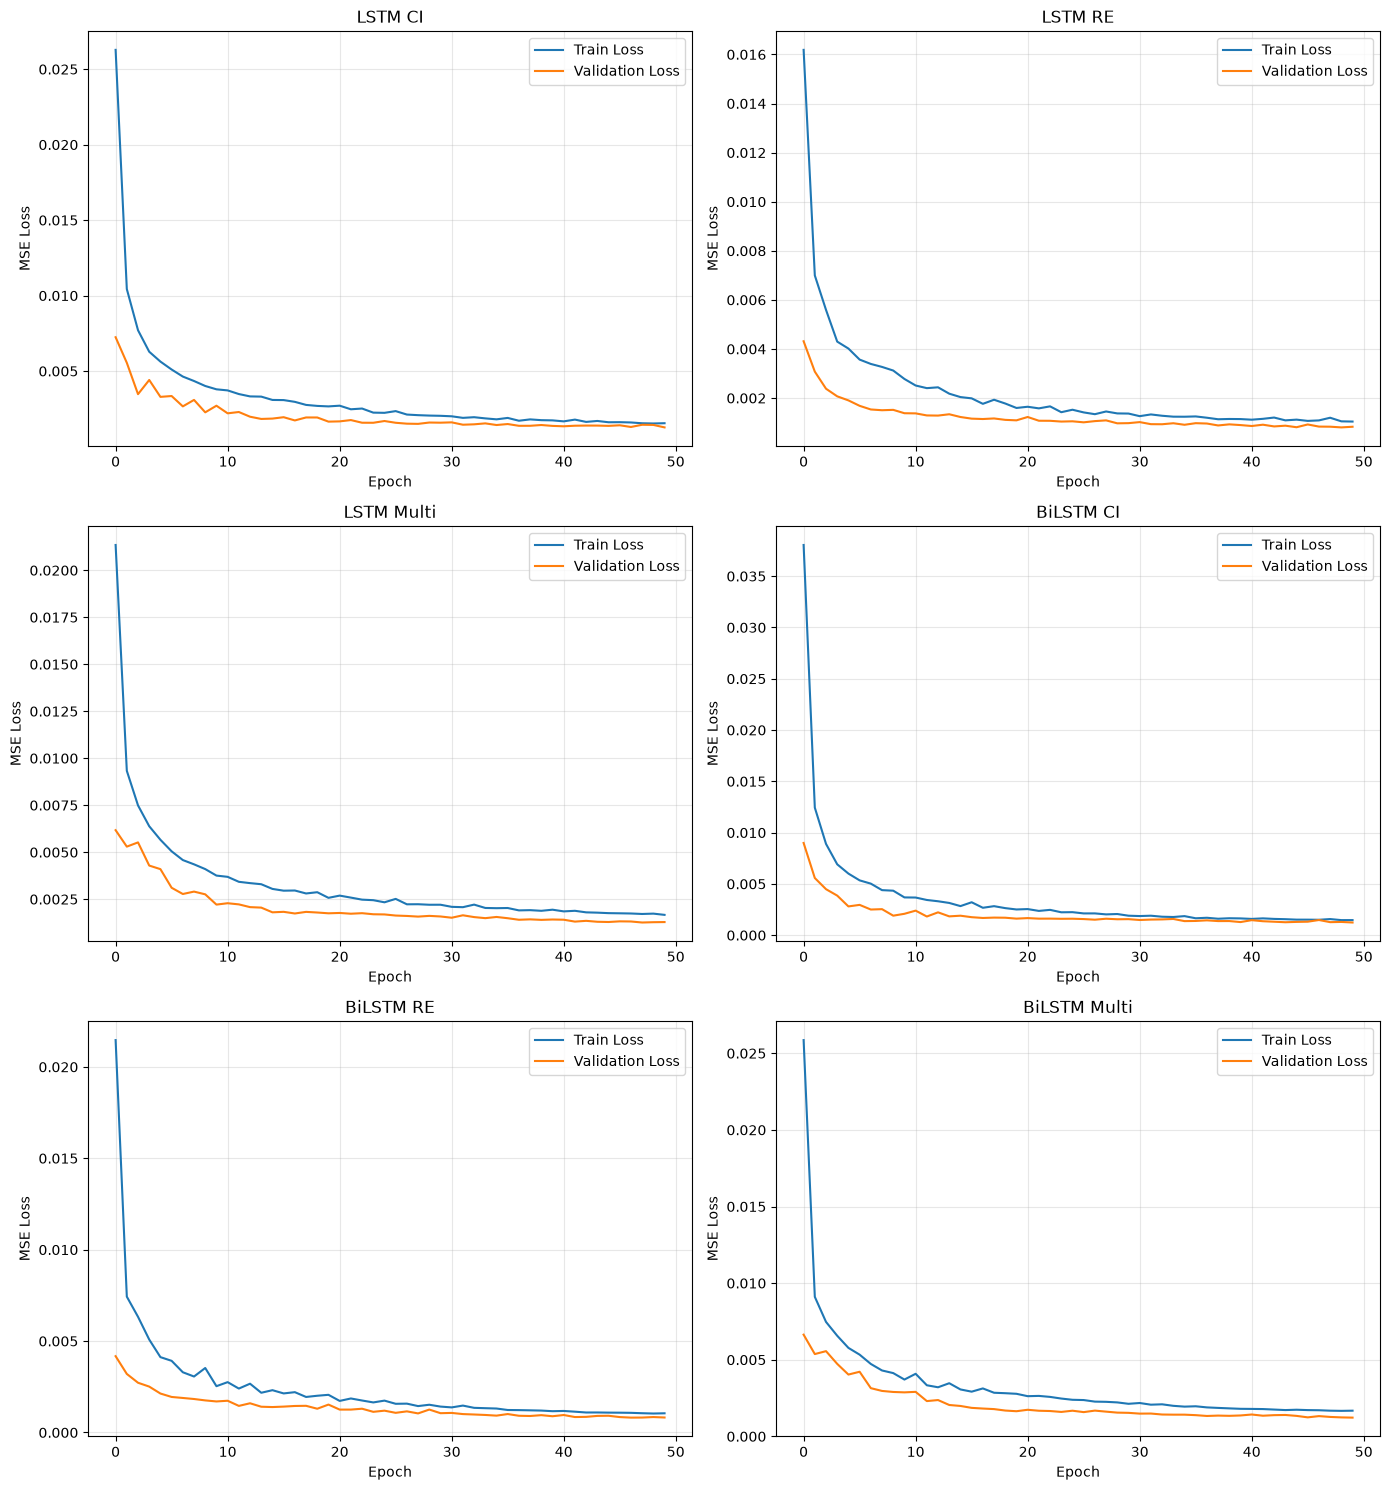

In [13]:
# Plot training histories
histories = {
    "LSTM CI": history_lstm_ci,
    "LSTM RE": history_lstm_re,
    "LSTM Multi": history_lstm_multi,
    "BiLSTM CI": history_bilstm_ci,
    "BiLSTM RE": history_bilstm_re,
    "BiLSTM Multi": history_bilstm_multi,
}

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

for ax, (name, history) in zip(axes, histories.items()):
    ax.plot(history.history["loss"], label="Train Loss")
    ax.plot(history.history["val_loss"], label="Validation Loss")
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [14]:
# Generate predictions in scaled space
pred_lstm_ci = model_lstm_ci.predict(
    X_test_ci,
    verbose=0
).reshape(-1)

pred_lstm_re = model_lstm_re.predict(
    X_test_re,
    verbose=0
).reshape(-1)

pred_lstm_multi = model_lstm_multi.predict(
    X_test_multi,
    verbose=0
)

pred_bilstm_ci = model_bilstm_ci.predict(
    X_test_ci,
    verbose=0
).reshape(-1)

pred_bilstm_re = model_bilstm_re.predict(
    X_test_re,
    verbose=0
).reshape(-1)

pred_bilstm_multi = model_bilstm_multi.predict(
    X_test_multi,
    verbose=0
)


# ============================================================
# INVERSE TRANSFORM PREDICTIONS
# ============================================================

# CI → loader_ci
pred_lstm_ci_inv = loader_ci.inverse_transform_predictions(
    pred_lstm_ci,
    target_cols=[CI_COL],
    feature_cols=feature_cols_uni_ci
).reshape(-1)

pred_bilstm_ci_inv = loader_ci.inverse_transform_predictions(
    pred_bilstm_ci,
    target_cols=[CI_COL],
    feature_cols=feature_cols_uni_ci
).reshape(-1)


# RE → loader_re
pred_lstm_re_inv = loader_re.inverse_transform_predictions(
    pred_lstm_re,
    target_cols=[RE_COL],
    feature_cols=feature_cols_uni_re
).reshape(-1)

pred_bilstm_re_inv = loader_re.inverse_transform_predictions(
    pred_bilstm_re,
    target_cols=[RE_COL],
    feature_cols=feature_cols_uni_re
).reshape(-1)


# Multi → loader_multi
pred_lstm_multi_inv = loader_multi.inverse_transform_predictions(
    pred_lstm_multi,
    target_cols=[CI_COL, RE_COL],
    feature_cols=feature_cols_multi
)

pred_bilstm_multi_inv = loader_multi.inverse_transform_predictions(
    pred_bilstm_multi,
    target_cols=[CI_COL, RE_COL],
    feature_cols=feature_cols_multi
)


# ============================================================
# INVERSE TRANSFORM ACTUAL VALUES
# ============================================================

# CI actual → loader_ci
y_lstm_ci_inv = loader_ci.inverse_transform_predictions(
    y_test_ci,
    target_cols=[CI_COL],
    feature_cols=feature_cols_uni_ci
).reshape(-1)


# RE actual → loader_re
y_lstm_re_inv = loader_re.inverse_transform_predictions(
    y_test_re,
    target_cols=[RE_COL],
    feature_cols=feature_cols_uni_re
).reshape(-1)


# Multi actual → loader_multi
y_multi_inv = loader_multi.inverse_transform_predictions(
    y_test_multi,
    target_cols=[CI_COL, RE_COL],
    feature_cols=feature_cols_multi
)

print("Prediction generation + inverse transform completed.")

Prediction generation + inverse transform completed.


In [15]:
# Evaluation helpers
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0
    if not np.any(mask):
        return np.nan

    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = safe_mape(y_true, y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = np.nan if ss_tot == 0 else 1 - (ss_res / ss_tot)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2
    }


results = []

def add_result(model_name, target, y_true, y_pred):
    metrics = regression_metrics(y_true, y_pred)

    results.append({
        "Model": model_name,
        "Target": target,
        **metrics
    })


# CI models
add_result(
    "Uni-LSTM CI",
    "CI",
    y_lstm_ci_inv,
    pred_lstm_ci_inv
)

add_result(
    "BiLSTM CI",
    "CI",
    y_lstm_ci_inv,
    pred_bilstm_ci_inv
)

add_result(
    "Multi-LSTM",
    "CI",
    y_multi_inv[:, 0],
    pred_lstm_multi_inv[:, 0]
)

add_result(
    "BiLSTM Multi",
    "CI",
    y_multi_inv[:, 0],
    pred_bilstm_multi_inv[:, 0]
)

# RE models
add_result(
    "Uni-LSTM RE",
    "RE",
    y_lstm_re_inv,
    pred_lstm_re_inv
)

add_result(
    "BiLSTM RE",
    "RE",
    y_lstm_re_inv,
    pred_bilstm_re_inv
)

add_result(
    "Multi-LSTM",
    "RE",
    y_multi_inv[:, 1],
    pred_lstm_multi_inv[:, 1]
)

add_result(
    "BiLSTM Multi",
    "RE",
    y_multi_inv[:, 1],
    pred_bilstm_multi_inv[:, 1]
)

results_df = pd.DataFrame(results)

print("=== MODEL EVALUATION ===")
display(results_df.sort_values(["Target", "RMSE"]).reset_index(drop=True))


=== MODEL EVALUATION ===


,Model,Target,MAE,RMSE,MAPE (%),R2
0,BiLSTM Multi,CI,1.973882,2.513051,0.338596,0.922296
1,Multi-LSTM,CI,2.272468,2.837128,0.390279,0.900963
2,BiLSTM CI,CI,2.422640,2.917383,0.414998,0.895281
3,Uni-LSTM CI,CI,2.501396,2.979461,0.428254,0.890777
4,BiLSTM RE,RE,0.163042,0.217058,1.030124,0.956791
5,Uni-LSTM RE,RE,0.166286,0.218952,1.050371,0.956034
6,Multi-LSTM,RE,0.205904,0.265871,1.301234,0.935172
7,BiLSTM Multi,RE,0.219049,0.280200,1.381246,0.927996


In [16]:
# Best model per target based on RMSE
best_by_target = (
    results_df
    .sort_values(["Target", "RMSE"])
    .groupby("Target", as_index=False)
    .first()
)

print("=== BEST MODEL BY TARGET (RMSE) ===")
display(best_by_target)


=== BEST MODEL BY TARGET (RMSE) ===


,Target,Model,MAE,RMSE,MAPE (%),R2
0,CI,BiLSTM Multi,1.973882,2.513051,0.338596,0.922296
1,RE,BiLSTM RE,0.163042,0.217058,1.030124,0.956791


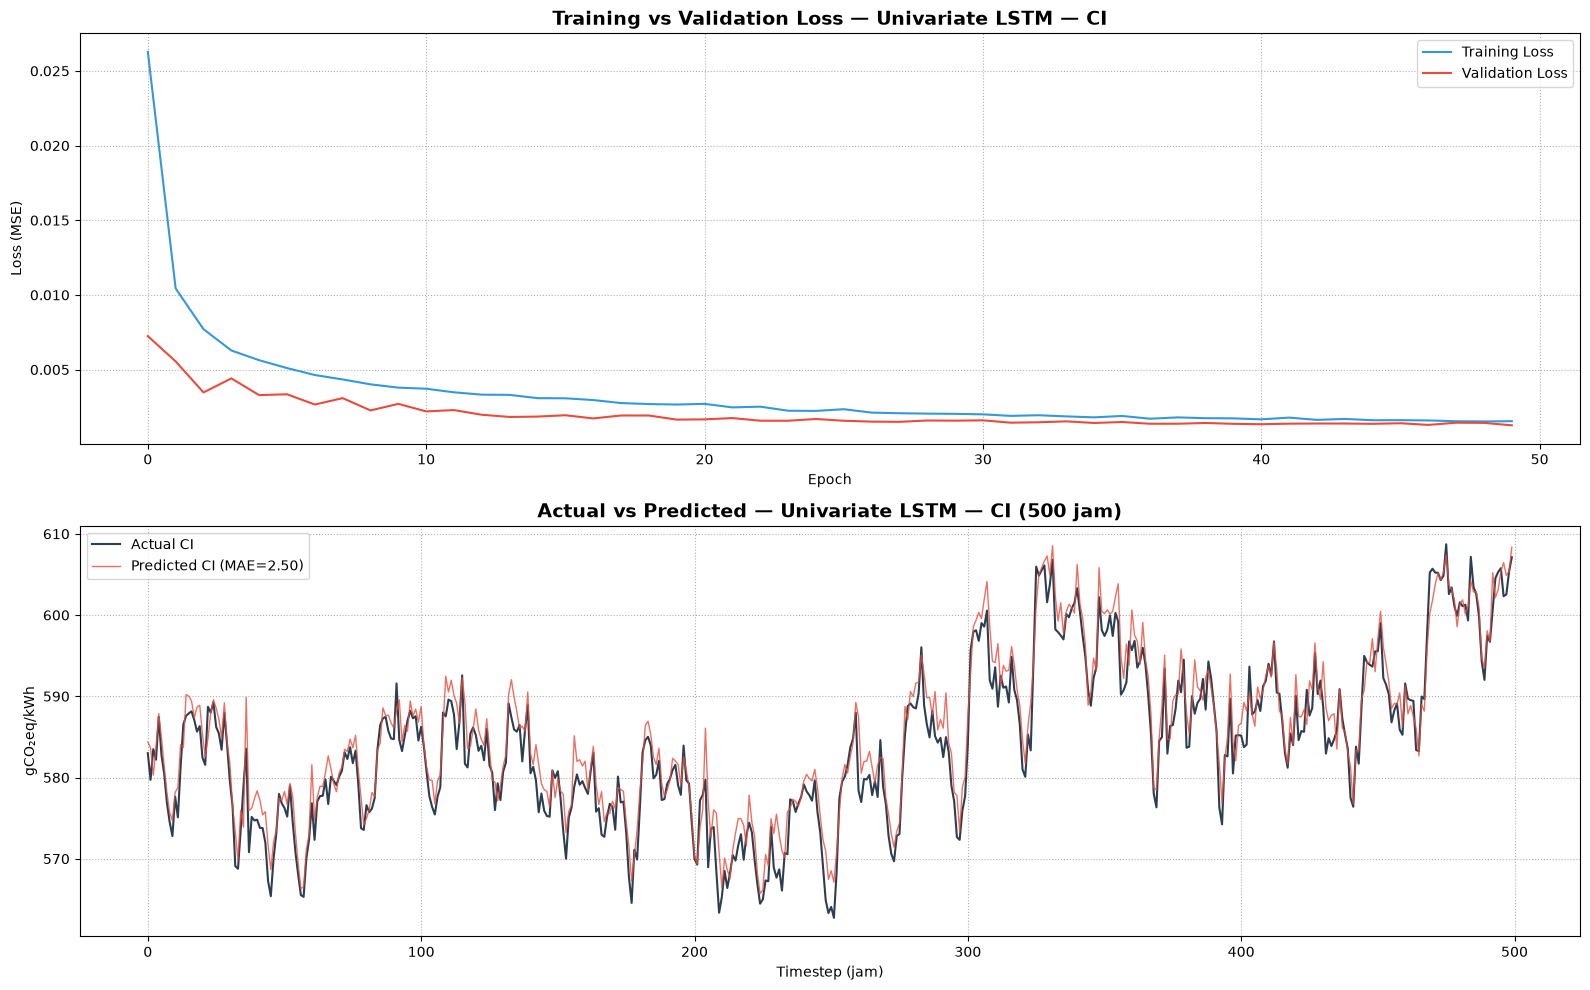

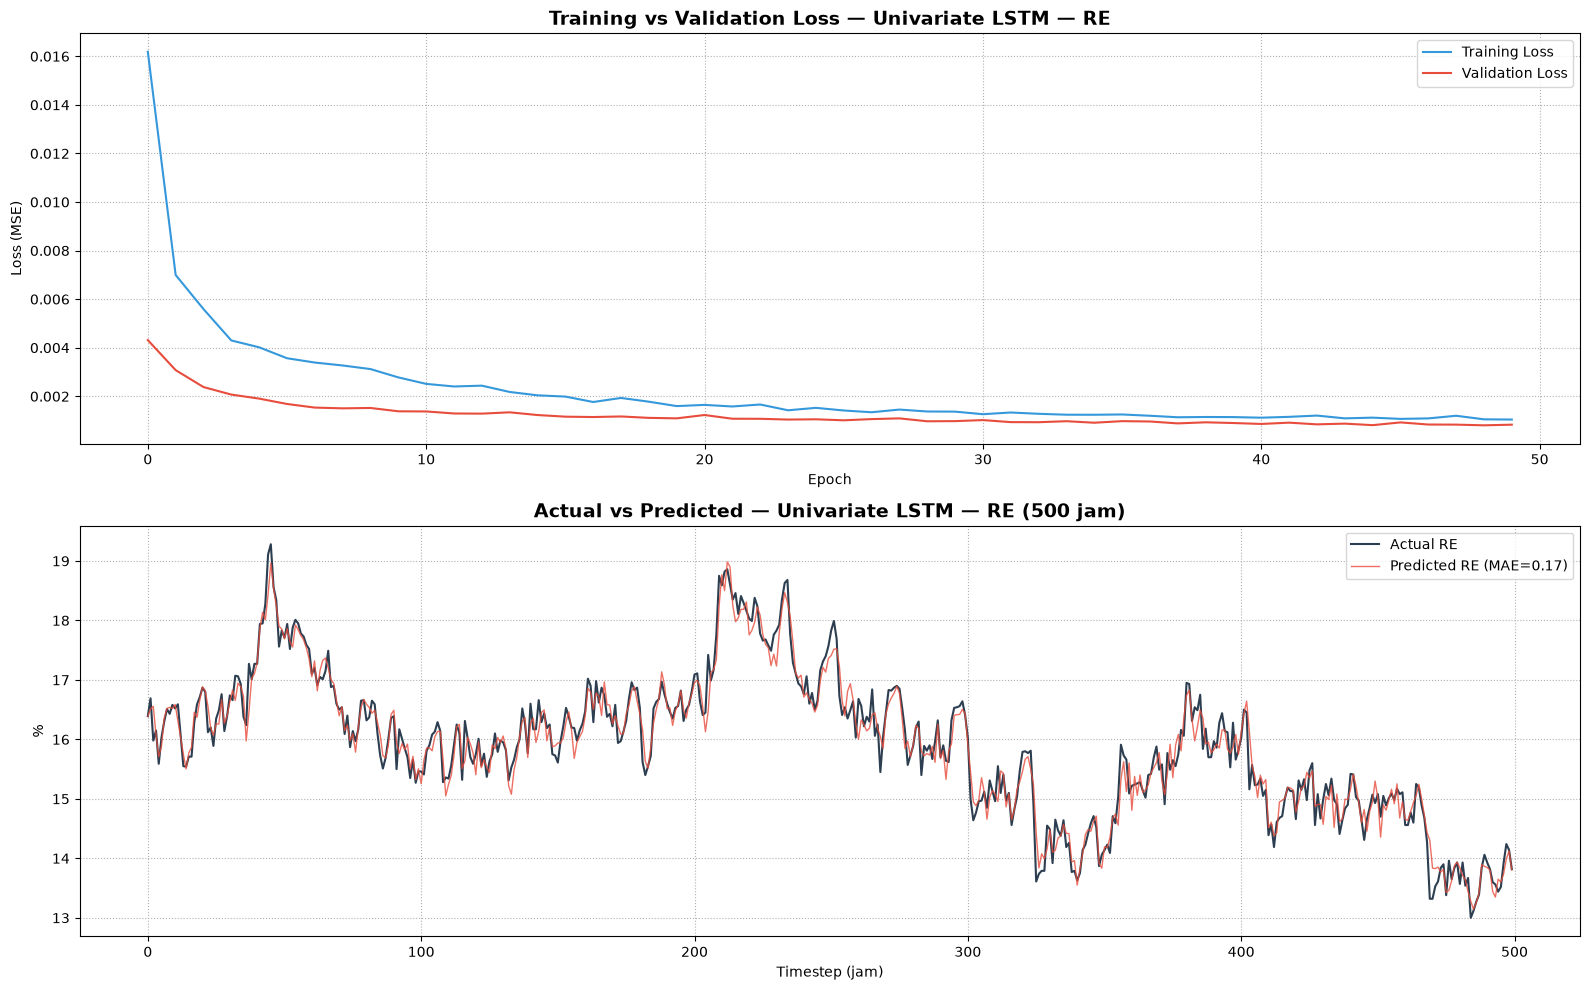

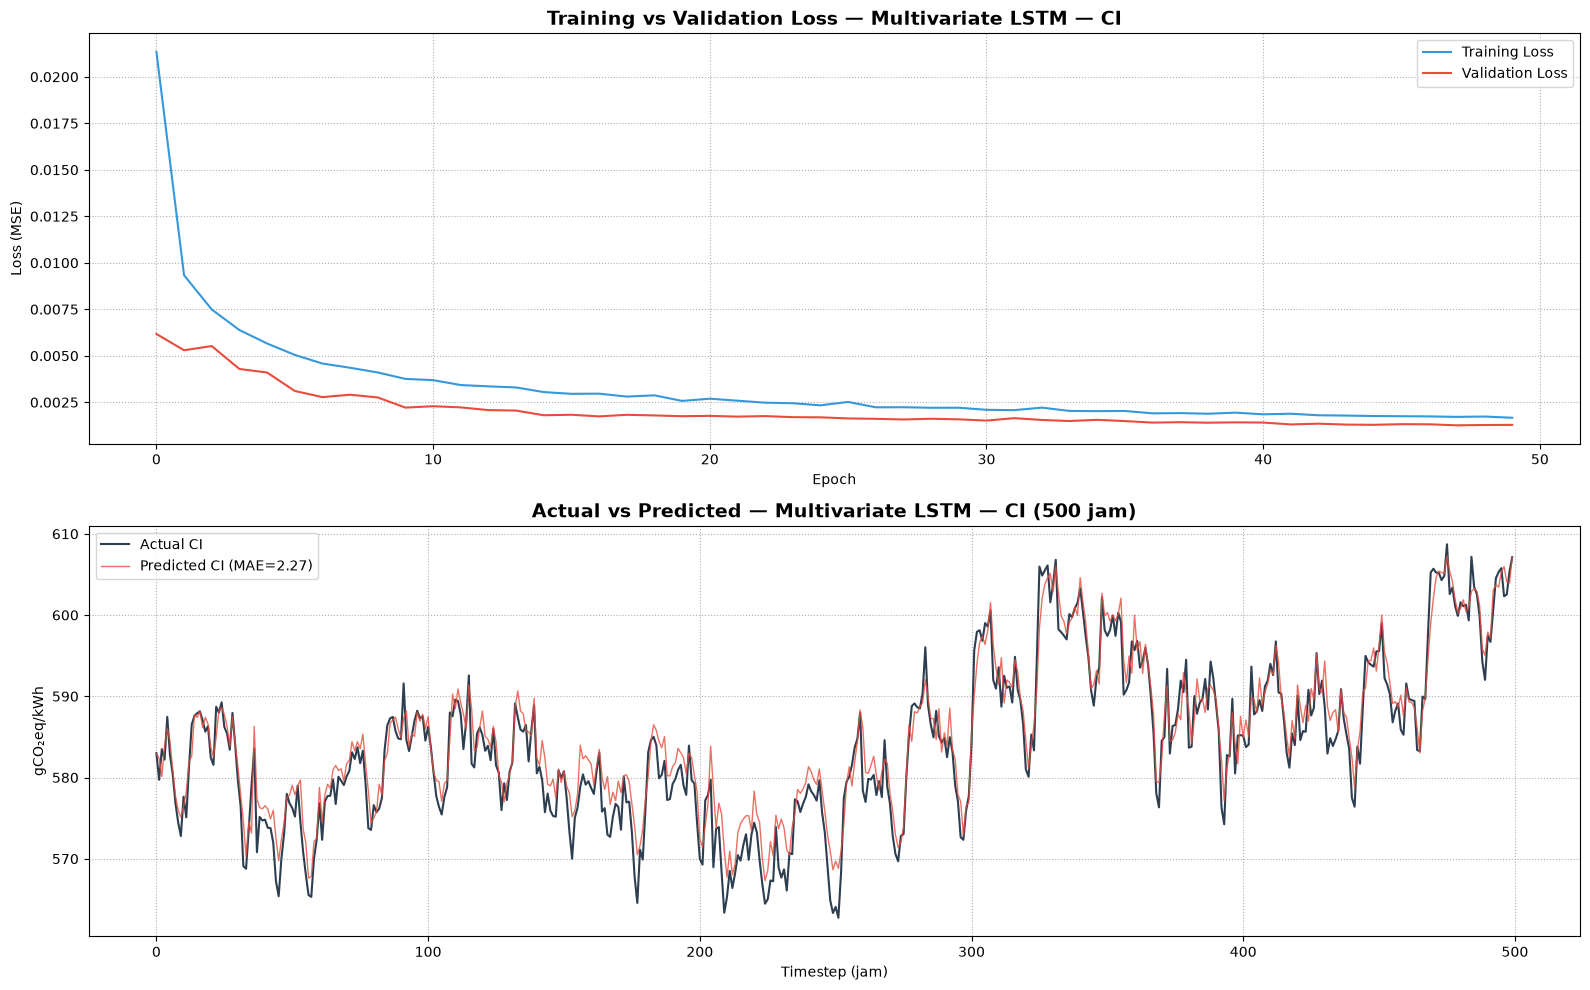

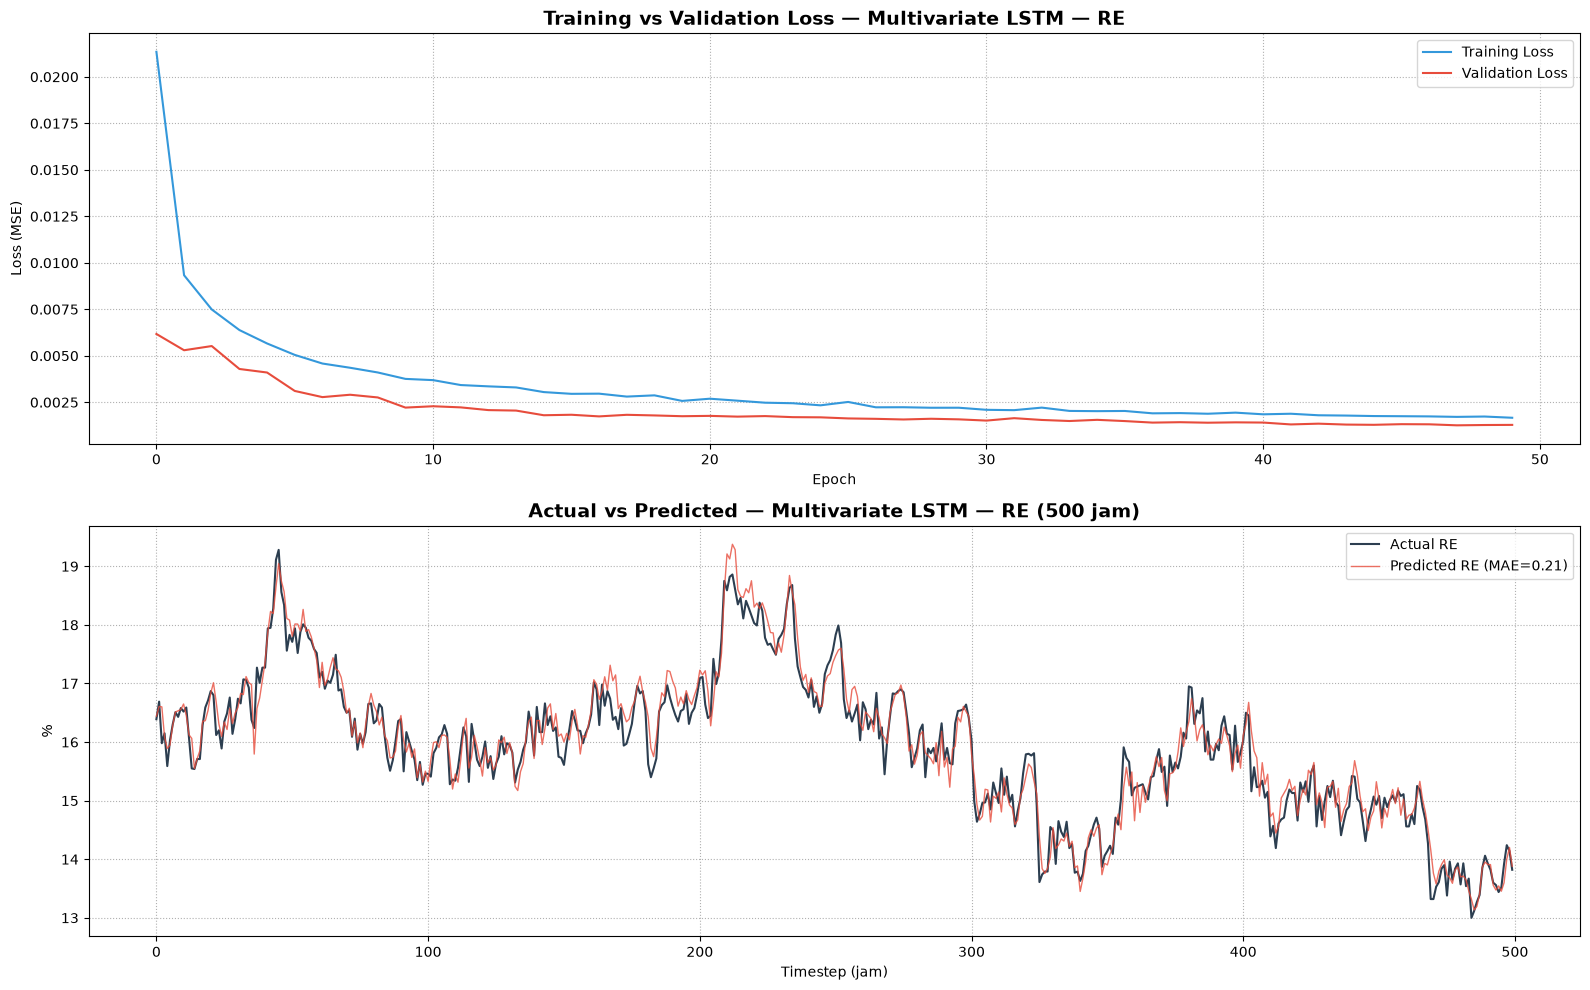

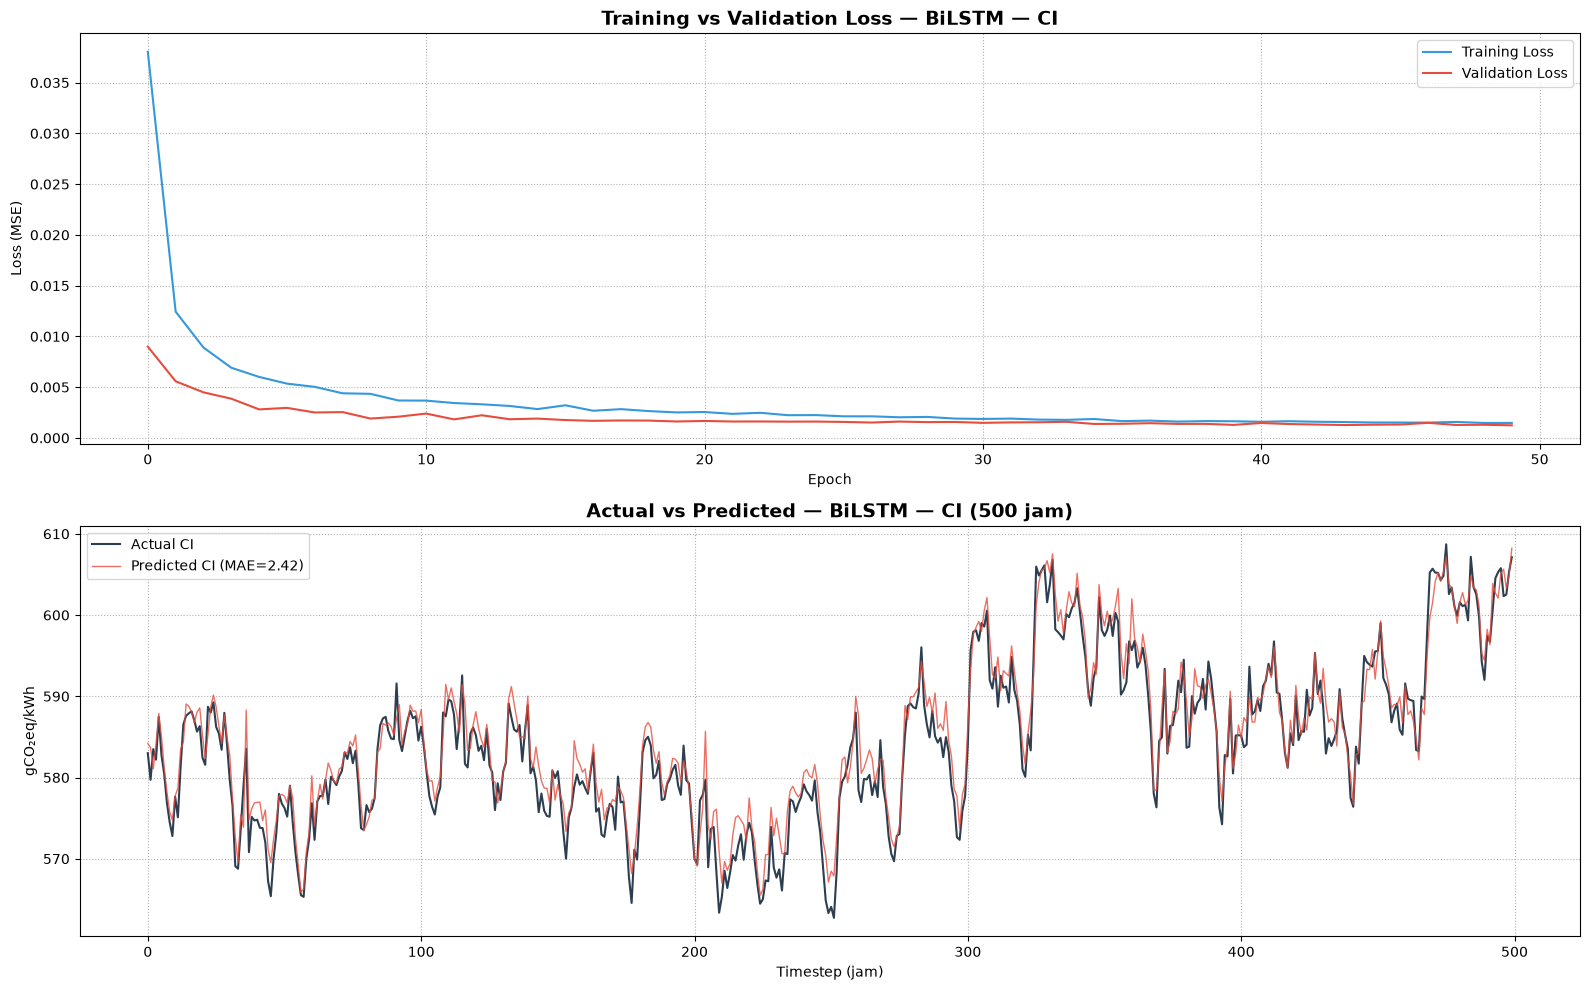

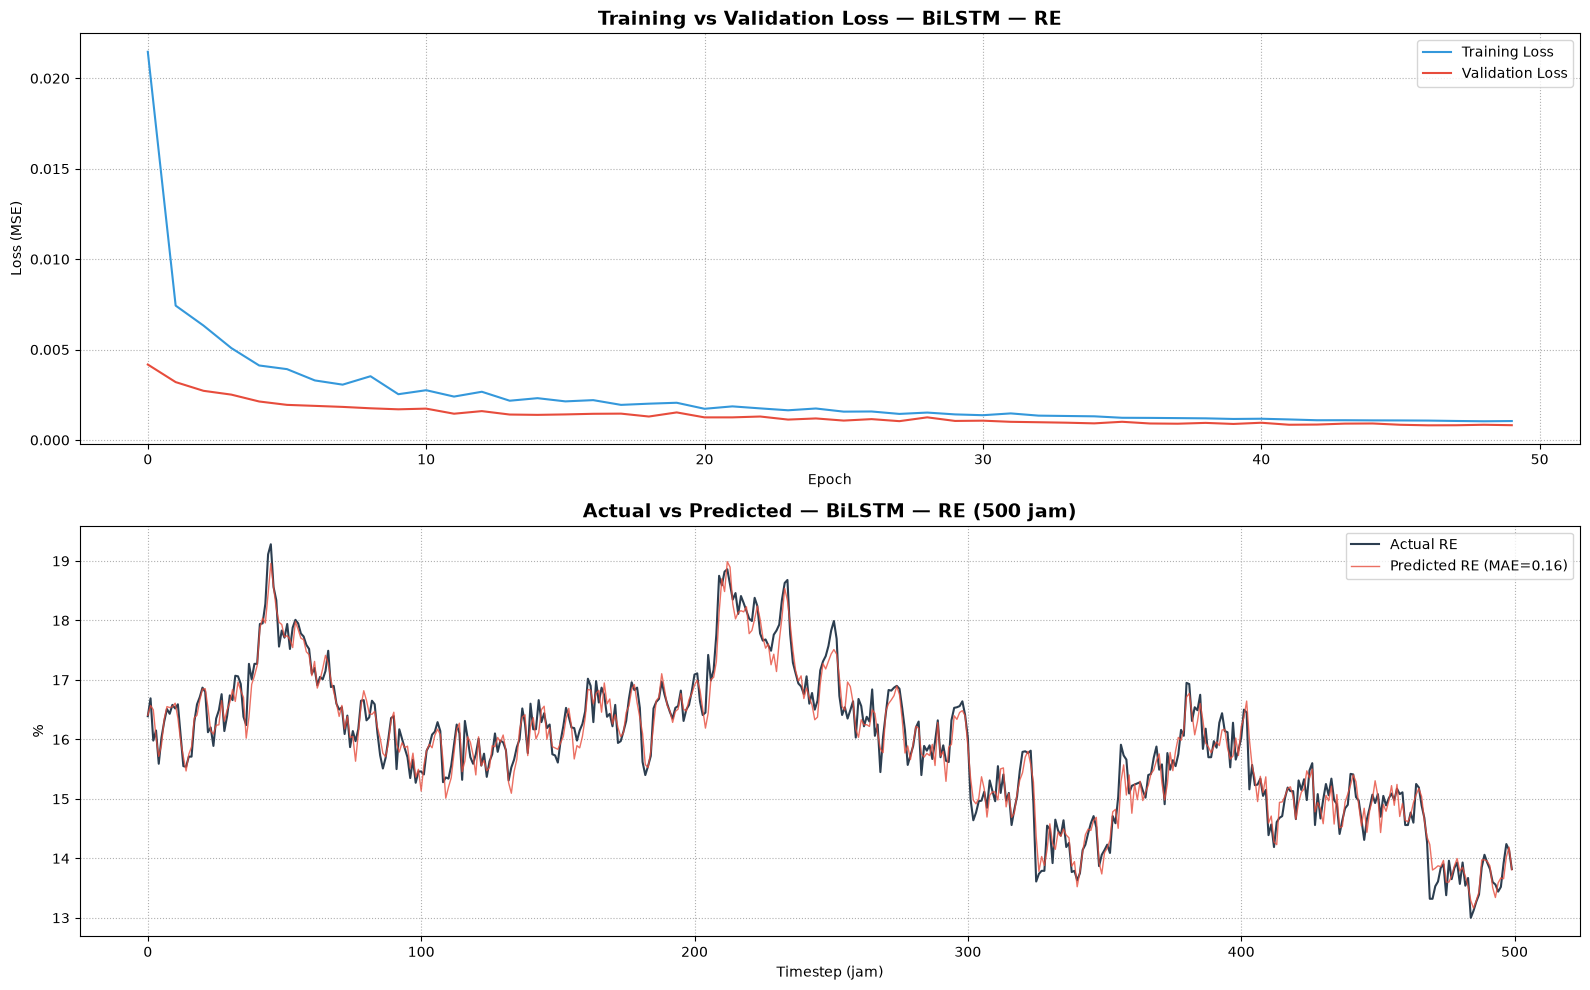

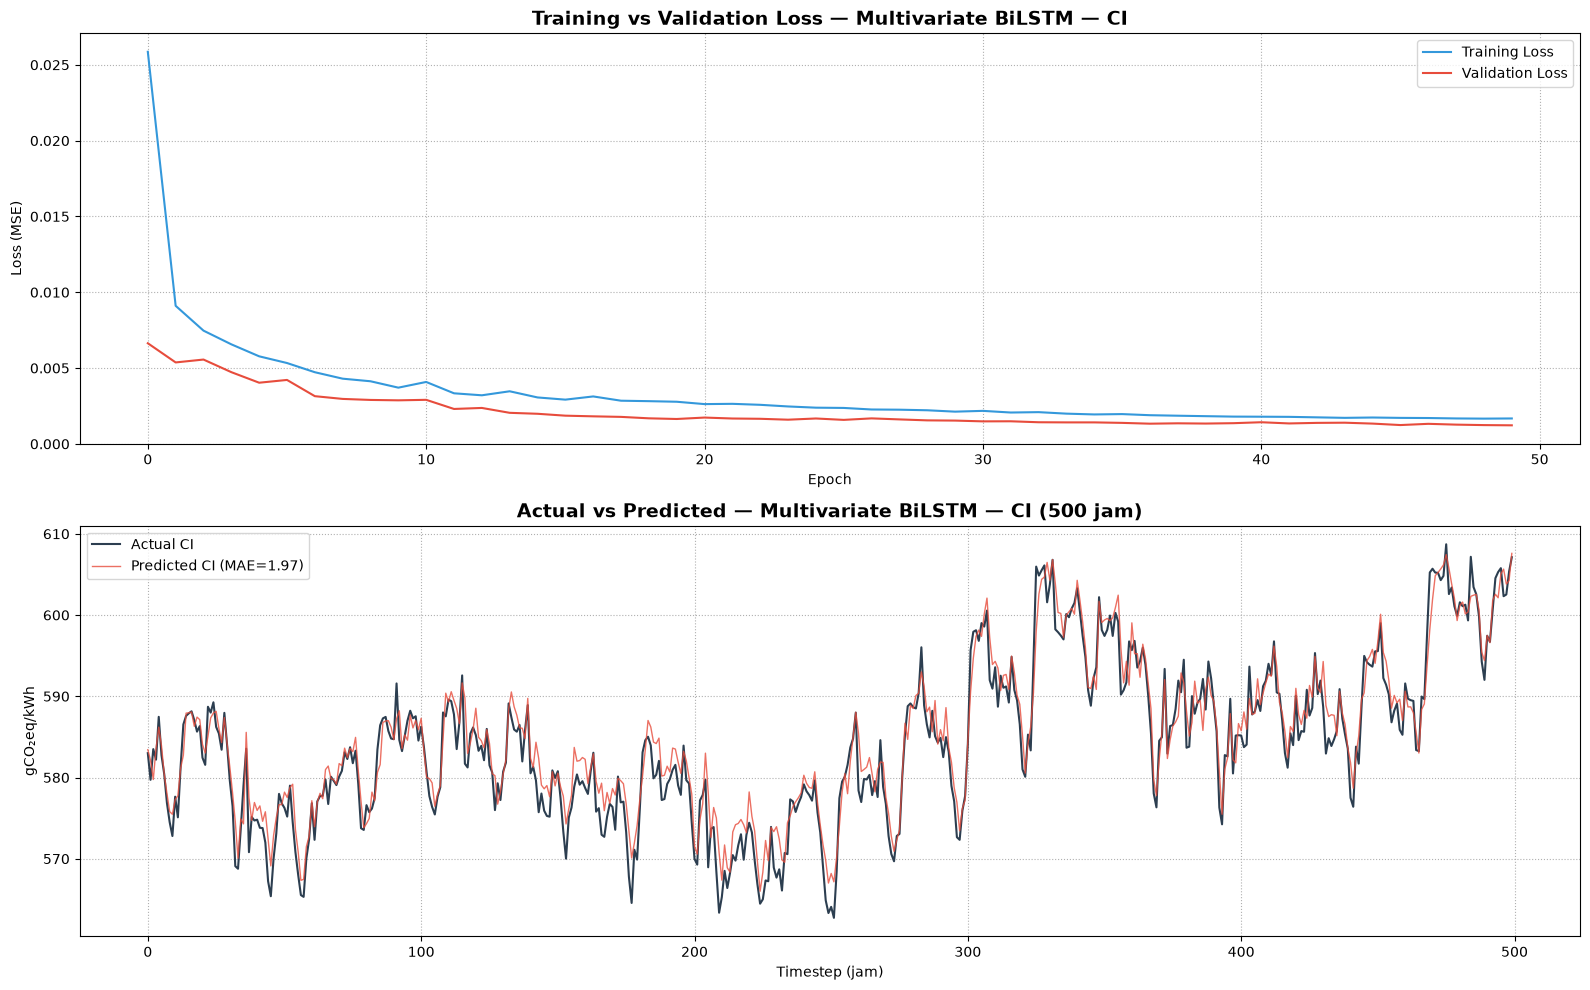

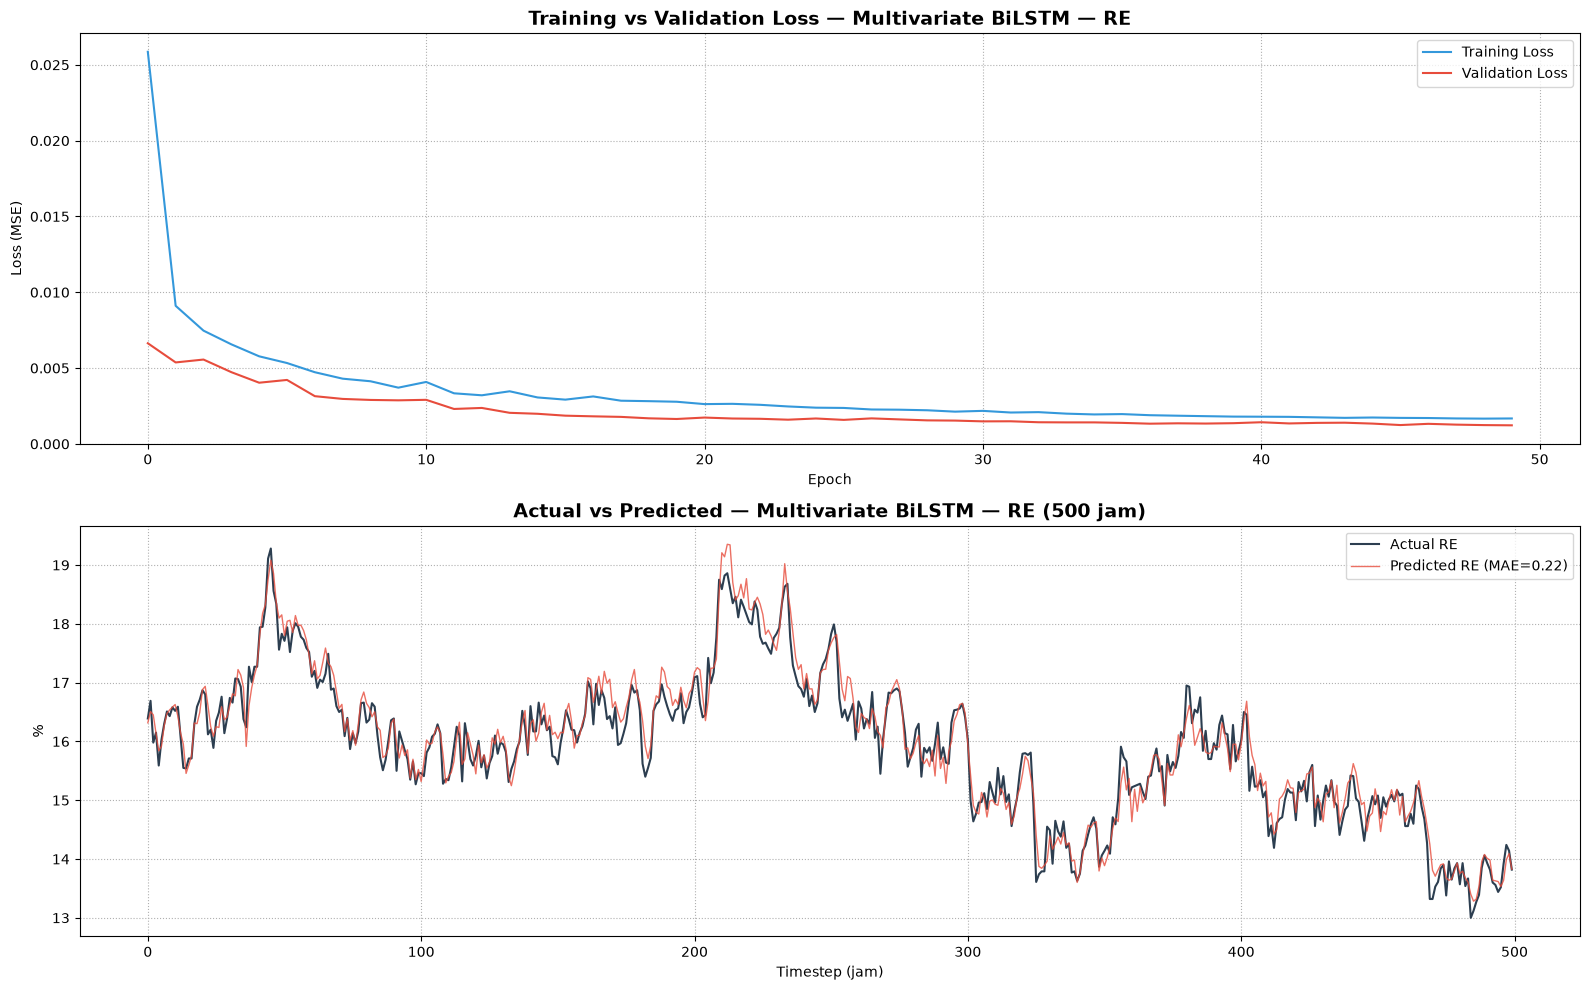

In [17]:
# Actual vs prediction plots for each model
def plot_model_evaluation(
    history,
    y_true,
    y_pred,
    model_name,
    target_name,
    unit="gCO₂eq/kWh",
    plot_hours=500
):
    mae = np.mean(np.abs(y_true - y_pred))
    plot_hours = min(plot_hours, len(y_true))

    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    # Loss curve
    axes[0].plot(
        history.history['loss'],
        label='Training Loss',
        color='#3498db'
    )
    axes[0].plot(
        history.history['val_loss'],
        label='Validation Loss',
        color='#e74c3c'
    )
    axes[0].set_title(
        f'Training vs Validation Loss — {model_name}',
        fontsize=14,
        fontweight='bold'
    )
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (MSE)')
    axes[0].legend()
    axes[0].grid(True, linestyle=':')

    # Actual vs Predicted
    axes[1].plot(
        y_true[:plot_hours],
        label=f'Actual {target_name}',
        color='#2c3e50',
        linewidth=1.5
    )
    axes[1].plot(
        y_pred[:plot_hours],
        label=f'Predicted {target_name} (MAE={mae:.2f})',
        color='#e74c3c',
        linewidth=1,
        alpha=0.8
    )
    axes[1].set_title(
        f'Actual vs Predicted — {model_name} ({plot_hours} jam)',
        fontsize=14,
        fontweight='bold'
    )
    axes[1].set_xlabel('Timestep (jam)')
    axes[1].set_ylabel(unit)
    axes[1].legend()
    axes[1].grid(True, linestyle=':')

    plt.tight_layout()
    plt.show()

# 1. Univariate LSTM — CI
plot_model_evaluation(
    history=history_lstm_ci,
    y_true=y_lstm_ci_inv,
    y_pred=pred_lstm_ci_inv,
    model_name="Univariate LSTM — CI",
    target_name="CI",
    unit="gCO₂eq/kWh"
)

# 2. Univariate LSTM — RE
plot_model_evaluation(
    history=history_lstm_re,
    y_true=y_lstm_re_inv,
    y_pred=pred_lstm_re_inv,
    model_name="Univariate LSTM — RE",
    target_name="RE",
    unit="%"
)

# 3. Multivariate LSTM — CI
plot_model_evaluation(
    history=history_lstm_multi,
    y_true=y_multi_inv[:, 0],
    y_pred=pred_lstm_multi_inv[:, 0],
    model_name="Multivariate LSTM — CI",
    target_name="CI",
    unit="gCO₂eq/kWh"
)

# 4. Multivariate LSTM — RE
plot_model_evaluation(
    history=history_lstm_multi,
    y_true=y_multi_inv[:, 1],
    y_pred=pred_lstm_multi_inv[:, 1],
    model_name="Multivariate LSTM — RE",
    target_name="RE",
    unit="%"
)

# 5. BiLSTM — CI
plot_model_evaluation(
    history=history_bilstm_ci,
    y_true=y_lstm_ci_inv,
    y_pred=pred_bilstm_ci_inv,
    model_name="BiLSTM — CI",
    target_name="CI",
    unit="gCO₂eq/kWh"
)

# 6. BiLSTM — RE
plot_model_evaluation(
    history=history_bilstm_re,
    y_true=y_lstm_re_inv,
    y_pred=pred_bilstm_re_inv,
    model_name="BiLSTM — RE",
    target_name="RE",
    unit="%"
)

# 7. Multivariate BiLSTM — CI
plot_model_evaluation(
    history=history_bilstm_multi,
    y_true=y_multi_inv[:, 0],
    y_pred=pred_bilstm_multi_inv[:, 0],
    model_name="Multivariate BiLSTM — CI",
    target_name="CI",
    unit="gCO₂eq/kWh"
)

# 8. Multivariate BiLSTM — RE
plot_model_evaluation(
    history=history_bilstm_multi,
    y_true=y_multi_inv[:, 1],
    y_pred=pred_bilstm_multi_inv[:, 1],
    model_name="Multivariate BiLSTM — RE",
    target_name="RE",
    unit="%"
)


In [18]:
# Save evaluation results
results_dir = (
    project_root
    / "results"
    / "deep_learning"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

results_path = results_dir / "05_dani_dl_cyclical_metrics.csv"
results_df.to_csv(results_path, index=False)

print("Results saved to:")
print(results_path)


Results saved to:
/Volumes/Livia's Storage/Users/Documents/Telkom_University/Outside_Classes/Research/CarbonIntensityResearch/app/results/deep_learning/05_dani_dl_cyclical_metrics.csv


In [19]:
# Save trained models
models_dir = (
    project_root
    / "models"
    / "deep_learning"
)

models_dir.mkdir(
    parents=True,
    exist_ok=True
)

model_lstm_ci.save(models_dir / "05_lstm_ci_cyclical.keras")
model_lstm_re.save(models_dir / "05_lstm_re_cyclical.keras")
model_lstm_multi.save(models_dir / "05_lstm_multi_cyclical.keras")
model_bilstm_ci.save(models_dir / "05_bilstm_ci_cyclical.keras")
model_bilstm_re.save(models_dir / "05_bilstm_re_cyclical.keras")
model_bilstm_multi.save(models_dir / "05_bilstm_multi_cyclical.keras")

print("All six trained models saved.")


All six trained models saved.


## Experiment Summary

Notebook ini menghasilkan enam model Deep Learning tanpa decomposition dengan cyclical temporal features.

Model yang dibandingkan:
1. Uni-LSTM CI
2. Uni-LSTM RE
3. Multi-LSTM
4. BiLSTM CI
5. BiLSTM RE
6. BiLSTM Multi

Hasil utama disimpan dalam:
`results/deep_learning/05_dani_dl_cyclical_metrics.csv`

Model tersimpan dalam:
`models/deep_learning/`
